# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     | Valeria Guzmán Galván  |
| **Fecha**      | 05/03/2026  |
| **Expediente** | 756902  |

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Default.csv to Default.csv


In [3]:
obj = pd.read_csv("Default.csv")

2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [4]:
obj = pd.read_csv("Default.csv")

In [5]:
obj.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [6]:
obj.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

El DataFrame contiene 4 columnas:

* default: contiene datos categóricos, ya que indica si el cliente dejó de pagar el crédito (Yes o No).

* student: contiene datos categóricos, porque indica si la persona es estudiante (Yes o No).

* balance: contiene datos numéricos continuos, ya que representa el saldo o deuda en la tarjeta de crédito.

* income: contiene datos numéricos continuos, porque representa el ingreso anual del cliente.

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [7]:
obj["default"] = obj["default"].astype("category")
obj["student"] = obj["student"].astype("category")

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

**Nota:**
* column: variable numérica que quieres analizar
* by: variable que agrupa los datos

<Axes: title={'center': 'income'}, xlabel='default'>

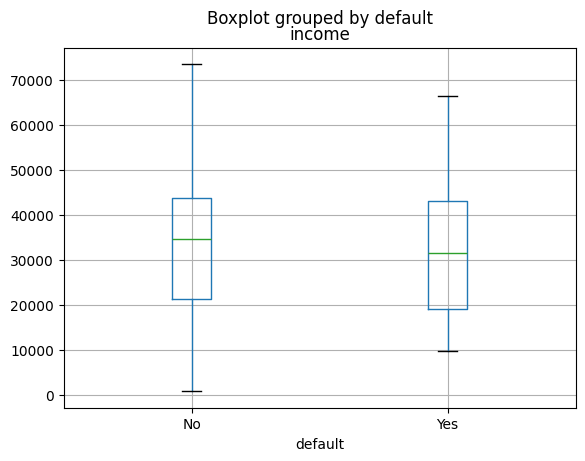

In [8]:
obj.boxplot(column="income", by="default")

**Interpretación:** Los ingresos de las personas que pagan y de las que no pagan son muy similares. Las medianas están casi al mismo nivel.

<Axes: title={'center': 'balance'}, xlabel='default'>

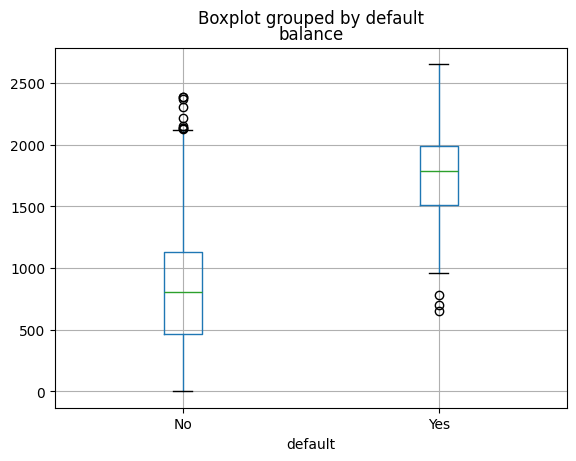

In [9]:
obj.boxplot(column="balance", by="default")

**Interpretación:** Las personas que no dejaron de pagar tienen balances más bajos. Las personas que sí dejaron de pagar tienen balances mucho más altos.

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

<Axes: xlabel='balance', ylabel='income'>

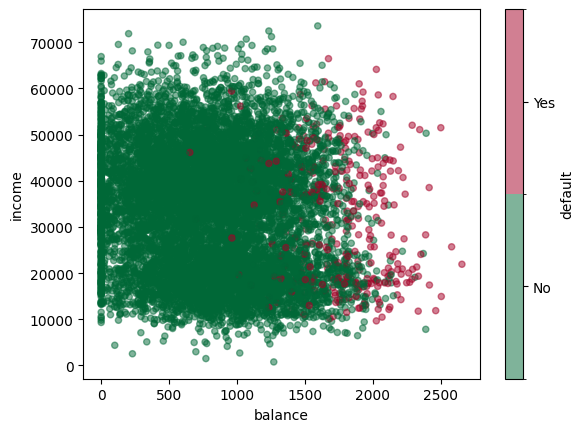

In [10]:
obj.plot.scatter(x="balance", y="income", c="default", colormap="RdYlGn_r", alpha=0.5)

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías.

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [11]:
# Esto convierte la columna default en valores booleanos
y = (obj["default"] == "Yes").astype(int)
y.head()

,default
0,0
1,0
2,0
3,0
4,0


In [12]:
x = obj[["balance"]]

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

In [13]:
obj["default_num"] = y

<Axes: xlabel='balance', ylabel='default_num'>

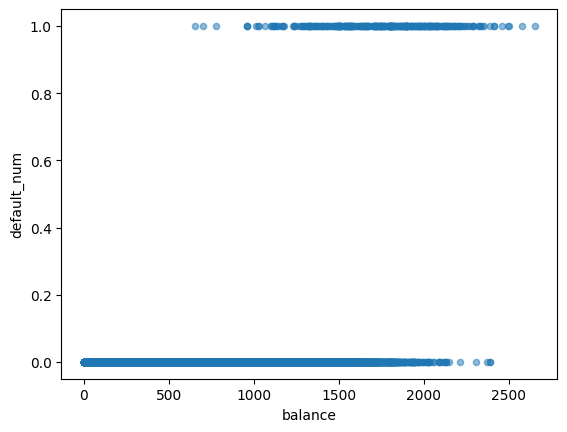

In [14]:
obj.plot.scatter(x="balance", y="default_num", alpha=0.5)

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
model = LogisticRegression()

In [17]:
model.fit(x, y)

LogisticRegression()

In [18]:
model.intercept_

array([-10.65132824])

In [19]:
model.coef_

array([[0.00549892]])

Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [20]:
import numpy as np

In [21]:
b0 = model.intercept_[0]
b1 = model.coef_[0][0]

In [22]:
p_hat = 1 / (1 + np.exp(-(b0 + b1 * x["balance"])))
p_hat

,balance
0,0.001306
1,0.002113
2,0.008595
3,0.000434
4,0.001777
...,...
9995,0.001183
9996,0.001526
9997,0.002467
9998,0.116760


2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [23]:
p_error = p_hat * (1 - p_hat)

In [24]:
p_error

,balance
0,0.001304
1,0.002108
2,0.008521
3,0.000434
4,0.001774
...,...
9995,0.001182
9996,0.001524
9997,0.002460
9998,0.103127


3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [25]:
V = np.diagflat(p_error)

4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [26]:
# Matriz X con intercepto y balance
X = np.hstack((np.ones((x.shape[0],1)), x))

In [27]:
cov = np.linalg.inv(X.T @ V @ X)

5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [28]:
se = np.sqrt(np.diag(cov))
se

array([3.61168600e-01, 2.20376169e-04])

Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [29]:
beta = np.array([b0, b1])

In [30]:
z = beta / se
z

array([-29.49129089,  24.95240552])

Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [31]:
from scipy.stats import norm

In [32]:
p_value = 2 * (1 - norm.cdf(abs(z)))
p_value

array([0., 0.])

¿Es significativa la relación de los factores con la variable de respuesta?

Sí, la relación es estadísticamente significativa. Los p-values obtenidos son aproximadamente 0, lo cual es menor que el nivel de significancia típico de 0.05. Esto indica que el factor balance tiene una relación significativa con la probabilidad de default.

Repite el procedimiento con el factor `student`.
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes.
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [33]:
x = (obj["student"] == "Yes").astype(int).values.reshape(-1,1)
y = (obj["default"] == "Yes").astype(int)

In [34]:
model = LogisticRegression()

In [35]:
model.fit(x, y)

LogisticRegression()

In [36]:
b0 = model.intercept_[0]
b1 = model.coef_[0][0]

In [37]:
p_hat = 1 / (1 + np.exp(-(b0 + b1 * x)))

In [38]:
p_error = p_hat * (1 - p_hat)

In [39]:
V = np.diagflat(p_error)

In [40]:
X = np.hstack((np.ones((x.shape[0],1)), x))
cov = np.linalg.inv(X.T @ V @ X)

In [41]:
se = np.sqrt(np.diag(cov))
se

array([0.07066143, 0.11522061])

In [42]:
beta = np.array([b0, b1])
z = beta / se
z

array([-49.56838058,   3.4386979 ])

In [43]:
p_value = 2 * (1 - norm.cdf(abs(z)))
p_value

array([0.        , 0.00058452])

**¿Es significativa la relación de los factores con la variable de respuesta?:**

Sí, los factores son significativos porque los p-values obtenidos son menores que 0.05. Esto indica que existe una relación estadísticamente significativa entre student y default.

## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*.

In [44]:
x1 = obj["balance"].values
x2 = obj["income"].values
x3 = (obj["student"] == "Yes").astype(int).values

In [45]:
y = (obj["default"] == "Yes").astype(int)
X = np.column_stack((x1, x2, x3))

In [46]:
model = LogisticRegression()

In [47]:
model.fit(X, y)

LogisticRegression()

In [48]:
b0 = model.intercept_[0]
b1, b2, b3 = model.coef_[0]

In [49]:
p_hat = 1 / (1 + np.exp(-(b0 + b1*x1 + b2*x2 + b3*x3)))

In [50]:
p_error = p_hat * (1 - p_hat)
V = np.diagflat(p_error)

In [51]:
X_design = np.hstack((np.ones((X.shape[0],1)), X))

In [52]:
cov = np.linalg.inv(X_design.T @ V @ X_design)

se = np.sqrt(np.diag(cov))

In [53]:
beta = np.array([b0, b1, b2, b3])

z = beta / se
z

array([-22.10609473,  24.73549998,   0.48262896,  -2.59132225])

In [54]:
p_value = 2 * (1 - norm.cdf(abs(z)))

p_value

array([0.        , 0.        , 0.62935921, 0.00956079])

**¿Los factores son significativos?**

Utilizando un nivel de significancia de 0.05, se observa que los factores balance y student tienen p-values menores que 0.05, por lo que se consideran estadísticamente significativos para explicar la probabilidad de default.

En cambio, el factor income tiene un p-value mayor que 0.05, lo que indica que no presenta una relación significativa con la variable de respuesta cuando se incluyen todos los factores en el modelo.

¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

**Spam en correo electrónico:**
Si un correo importante se clasifica como spam (falso positivo), el usuario podría perder información relevante, como mensajes de trabajo o confirmaciones importantes.

**Detección de plagio en trabajos académicos:**
Si un sistema marca un trabajo original como plagio, el estudiante podría enfrentar sanciones injustas.

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

**Detección de armas en aeropuertos:**
Si el sistema no detecta un objeto peligroso cuando realmente está presente, se pone en riesgo la seguridad de las personas.

**Control de calidad:**
Si un producto defectuoso no es detectado por el sistema de revisión, puede llegar al cliente y causar problemas.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3